## Libraries

In [6]:
import json
from io import BytesIO

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import xgboost
from IPython.display import Image, display
from matplotlib.ticker import PercentFormatter
from tensorflow.keras.models import load_model

## Parameters

In [7]:
FILENAME = 'libs/BTCUSDT-M5.csv'
M1_MODEL_PATH = 'libs/M1-T0_8500.keras'
start_time = "2025-08-06 00:00:00"
end_time = "2026-09-28 00:00:00"
window_plot = 200000

# Backtesting parameters
FEE_BPS = 0.0  # Total fee per trade, in basis points.
TIME_LIMIT = 120
M2_ATR_PERIOD = 100
APPLY_DISTANCE_FILTER = True

WARMUP_BARS = 1500

## Load model settings

In [8]:
with open('libs/splits.json') as file:
    SPLITS = json.load(file)
with open('libs/m2_thresholds.json') as file:
    thresholds = json.load(file)

models = []
with np.load('libs/m2_tree_ensemble.npz', allow_pickle=False) as bundle:
    model_settings = json.loads(bytes(bundle['meta']))
    for i in range(model_settings['n_models']):
        model = xgboost.XGBClassifier()
        model.load_model(bytearray(bundle[f'model_{i}'].tobytes()))
        models.append(model)

calibration = joblib.load('libs/m2_calibrator.pkl')

# Change these values to try another threshold or distance cap.
LONG_THRESHOLD = thresholds['long_threshold']
SHORT_THRESHOLD = thresholds['short_threshold']
M1_GATE = thresholds['m1_threshold']
SIGNAL_GAP = thresholds['m1_signal_gap']
CAP_LONG = thresholds['raw_max_target_pct_long']
CAP_SHORT = thresholds['raw_max_target_pct_short']
BARRIER_MULT_TRAIN = model_settings['barrier_mult']

SEQ_LEN = SPLITS['seq_len']
ROLLING_SPAN = SPLITS['rolling_span']
Z_CLIP = SPLITS['z_clip']

## Load data

In [9]:
df = pd.read_csv(FILENAME, index_col=0)
df.index = pd.to_datetime(df.index, format='%Y%m%d %H:%M:%S.%f')
df.index = df.index.tz_localize('Europe/Paris', ambiguous='infer').tz_convert('UTC')
df = df.loc[start_time:end_time].copy()

print(f'{len(df):,} candles | {df.index[0]} to {df.index[-1]}')

119,520 candles | 2025-08-06 00:00:00+00:00 to 2026-09-24 23:55:00+00:00


## EKF

Same as in training

In [ ]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'vol_estimate', 'q_multiplier',
         'norm_innovation', 'signed_observation_surprise',
         'level_uncertainty_norm', 'velocity_uncertainty_norm', 'filtered_velocity', 'target_price', 'target_velocity',
         'mode_prob_responsive', 'vol_process', 'dir_ratio', 'robust_scale',
         'open', 'high', 'low', 'close']]
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119520 entries, 2025-08-06 00:00:00+00:00 to 2026-09-24 23:55:00+00:00
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Open                         119520 non-null  float64
 1   High                         119520 non-null  float64
 2   Low                          119520 non-null  float64
 3   Close                        119520 non-null  float64
 4   Volume                       119520 non-null  int64  
 5   vol_estimate                 119520 non-null  float64
 6   q_multiplier                 119520 non-null  float64
 7   norm_innovation              119520 non-null  float64
 8   signed_observation_surprise  119520 non-null  float64
 9   level_uncertainty_norm       119520 non-null  float64
 10  velocity_uncertainty_norm    119520 non-null  float64
 11  filtered_velocity            119520 non-null  float64
 12  target_price

## M1

### Feature engineering

In [11]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    result = 100 * gain / (gain + loss)
    return result.mask((gain + loss).eq(0), 50.0)

def true_range(data):
    prev_close = data['Close'].shift(1)
    return pd.concat([data['High'] - data['Low'],
                      (data['High'] - prev_close).abs(),
                      (data['Low'] - prev_close).abs()], axis=1).max(axis=1)

def _m1_segment_features(data):
    data = data.copy()
    c, o, h, l, v = (data[k] for k in ['Close', 'Open', 'High', 'Low', 'Volume'])
    floor = (c.abs() * 1e-8).clip(lower=1e-12)
    log_c = np.log(c)
    log_ret = log_c.diff()
    atr14 = true_range(data).rolling(14).mean()
    atr_safe = atr14.clip(lower=floor)
    dc_high, dc_low = h.rolling(20).max(), l.rolling(20).min()
    dc_range = dc_high - dc_low
    candle_range = h - l
    candle_safe = candle_range.clip(lower=floor)
    bb_mid, bb_std = c.rolling(20).mean(), c.rolling(20).std()

    data['feat_bb_width'] = 4 * bb_std / bb_mid
    data['feat_atr_norm'] = atr14 / c
    data['feat_dc_width'] = dc_range / c
    data['feat_dc_position20'] = ((c - dc_low) / dc_range.clip(lower=floor)).where(
        dc_range > floor, 0.5).clip(0, 1)
    data['feat_dist_high_atr20'] = (dc_high - c) / atr_safe
    data['feat_dist_low_atr20'] = (c - dc_low) / atr_safe
    data['feat_rsi'] = calculate_rsi(c)
    data['feat_rsi_roc'] = data['feat_rsi'].diff(3)
    macd = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    data['feat_macd_hist'] = (macd - macd.ewm(span=9, adjust=False).mean()) / atr_safe
    data['feat_roc_3'] = c.pct_change(3, fill_method=None)
    data['feat_roc_12'] = c.pct_change(12, fill_method=None)
    for horizon in [6, 24, 60]:
        data[f'feat_log_ret_{horizon}'] = log_c.diff(horizon)
    data['feat_hist_vol'] = log_ret.rolling(96).std()
    data['feat_ema_spread'] = (c.ewm(span=7, adjust=False).mean()
                               - c.ewm(span=25, adjust=False).mean()) / c
    data['feat_body_dominance'] = ((c - o).abs() / candle_safe).clip(0, 1)
    data['feat_signed_body_ratio'] = ((c - o) / candle_safe).clip(-1, 1)
    data['feat_upper_wick_ratio'] = ((h - data[['Open', 'Close']].max(axis=1))
                                     .clip(lower=0) / candle_safe).clip(0, 1)
    data['feat_lower_wick_ratio'] = ((data[['Open', 'Close']].min(axis=1) - l)
                                     .clip(lower=0) / candle_safe).clip(0, 1)
    data['feat_close_location'] = ((c - l) / candle_safe).where(
        candle_range > floor, 0.5).clip(0, 1)
    # The most recent occurrence wins when several candles share the extreme.
    data['feat_bars_since_high20'] = h.rolling(20).apply(lambda x: np.argmax(x[::-1]), raw=True)
    data['feat_bars_since_low20'] = l.rolling(20).apply(lambda x: np.argmin(x[::-1]), raw=True)

    evol = data['vol_estimate'].clip(lower=1e-10)
    raw_log_c = np.log(data['close'])
    data['feat_raw_filtered_gap_norm'] = (raw_log_c - log_c) / evol
    data['feat_raw_filtered_ret_diff'] = raw_log_c.diff() - log_ret
    ratio_floor = (0.01 * atr14).clip(lower=floor)
    data['feat_raw_filtered_range_ratio'] = (data['high'] - data['low']).clip(lower=0) / candle_range.clip(lower=ratio_floor)

    log_v = np.log1p(v.clip(lower=0))
    vol_ma = v.rolling(20).mean()
    data['feat_rvol'] = (v / vol_ma).mask(vol_ma.eq(0), 0.0)
    data['feat_vroc'] = log_v.diff(3)
    data['feat_vol_std'] = (v.rolling(20).std() / vol_ma).mask(vol_ma.eq(0), 0.0)
    vol_change = log_v.diff()
    corr = log_ret.rolling(12).corr(vol_change)
    constant = log_ret.rolling(12).std().eq(0) | vol_change.rolling(12).std().eq(0)
    data['feat_vol_price_corr'] = corr.mask(constant, 0.0).clip(-1, 1)

    vel = data['filtered_velocity']
    innov = log_c - (log_c.shift(1) + vel.shift(1))
    data['feat_innov_norm'] = innov / evol
    data['feat_innov_ema'] = data['feat_innov_norm'].ewm(span=20, adjust=False).mean()
    lag_innov = innov.shift(1)
    corr = innov.rolling(20).corr(lag_innov)
    constant = innov.rolling(20).std().eq(0) | lag_innov.rolling(20).std().eq(0)
    data['feat_innov_autocorr'] = corr.mask(constant, 0.0).clip(-1, 1)
    data['feat_innov_mag'] = data['norm_innovation'].ewm(span=20, adjust=False).mean()
    data['feat_signed_observation_surprise'] = data['signed_observation_surprise'].clip(-16, 16)
    data['feat_level_uncertainty'] = np.log1p(data['level_uncertainty_norm'])
    data['feat_velocity_uncertainty'] = np.log1p(data['velocity_uncertainty_norm'])
    data['feat_velocity_norm'] = vel / evol
    data['feat_accel_norm'] = vel.diff() / evol
    data['feat_velocity_change6'] = vel.diff(6) / evol
    pk = 1 / (2 * np.sqrt(np.log(2)))
    raw_pv = (np.log(h) - np.log(l)) * pk
    data['feat_vol_ratio'] = (raw_pv.ewm(span=ekf.vol_fast_span, adjust=False).mean()
                              / raw_pv.ewm(span=ekf.vol_slow_span, adjust=False).mean().clip(lower=1e-10))
    data['feat_vol_change'] = evol.diff() / evol
    data['feat_dir_consistency'] = np.sign(innov).rolling(10).mean()
    data['feat_ekf_log_ret'] = log_ret
    data['feat_mode_prob_responsive'] = data['mode_prob_responsive']
    data['feat_mode_prob_responsive_change'] = data['mode_prob_responsive'].diff()
    data['feat_vol_process'] = np.log(data['vol_process'].clip(lower=1e-10) / evol)
    data['feat_dir_ratio'] = data['dir_ratio']
    # Keep absolute volatility context alongside its rolling-normalized version.
    data['feat_vol_level'] = np.log1p(10000 * evol)
    data['feat_atr_level'] = np.log1p(10000 * atr14 / c)
    return data

def engineer_m1_features(frame):
    # Shared by M1 training, its prediction path, and M2's price inputs.
    data = frame.drop(columns=[c for c in frame if c.startswith('feat_')]).copy()
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    parts = [_m1_segment_features(part) for _, part in data.groupby(segments, sort=False)]
    result = pd.concat(parts).sort_index() if parts else data
    return result.replace([np.inf, -np.inf], np.nan)

def scale_model_features(frame, columns, affine, span=500, z_clip=8.0):
    data = frame.copy()
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    for col in columns:
        if col in affine:
            scale, offset = affine[col]
            data[col] = data[col] * scale + offset
        else:
            grouped = data[col].groupby(segments, sort=False)
            mean = grouped.transform(lambda x: x.ewm(span=span, min_periods=60).mean())
            std = grouped.transform(lambda x: x.ewm(span=span, min_periods=60).std()).clip(lower=1e-12)
            data[col] = ((data[col] - mean) / std).clip(-z_clip, z_clip)
    return data.replace([np.inf, -np.inf], np.nan)

def valid_window_ends(frame, columns, length):
    finite = np.isfinite(frame[columns].to_numpy(dtype=np.float32)).all(axis=1)
    ready = pd.Series(finite).rolling(length, min_periods=length).sum().eq(length).to_numpy()
    elapsed = frame.index.to_series() - frame.index.to_series().shift(length - 1)
    ready &= elapsed.eq((length - 1) * pd.Timedelta(ekf.bar_interval)).to_numpy()
    return np.flatnonzero(ready)

### Predictions

In [12]:
feature_cols = SPLITS['feature_cols']
M1_AFFINE_FEATURES = SPLITS['affine_features']
df = engineer_m1_features(df)
df = scale_model_features(df, feature_cols, M1_AFFINE_FEATURES, ROLLING_SPAN, Z_CLIP)

if len(df) < WARMUP_BARS + SEQ_LEN:
    print(f"WARNING: only {len(df)} rows after preprocessing, the EKF and the "
          f"EWM z-score need ~{WARMUP_BARS} bars of warm-up.")

end_rows = valid_window_ends(df, feature_cols, SEQ_LEN)
model_m1 = load_model(M1_MODEL_PATH)
assert model_m1.input_shape[-1] == len(feature_cols), 'M1 feature count does not match.'

# Build batches without keeping every overlapping window in memory.
X_scaled = tf.convert_to_tensor(df[feature_cols].to_numpy(dtype=np.float32))
offsets = tf.range(SEQ_LEN - 1, -1, -1, dtype=tf.int64)
X_inference = tf.data.Dataset.from_tensor_slices(end_rows.astype(np.int64)).batch(1024)
X_inference = X_inference.map(lambda ends: tf.gather(X_scaled, ends[:, None] - offsets[None, :]))
X_inference = X_inference.prefetch(tf.data.AUTOTUNE)
y_prob = model_m1.predict(X_inference, verbose=0).ravel() if len(end_rows) else np.empty(0)

df['predicted_prob'] = np.nan
df.loc[df.index[end_rows], 'predicted_prob'] = y_prob
df['predicted_signal'] = np.nan
df.loc[df.index[end_rows], 'predicted_signal'] = (y_prob >= M1_GATE).astype(int)
print(f'M1 signals: {int(df["predicted_signal"].sum()):,}')

df = df[['Open', 'Close', 'Low', 'High', 'Volume', 'predicted_prob',
         'predicted_signal', 'vol_estimate', 'q_multiplier', 'norm_innovation',
         'signed_observation_surprise', 'level_uncertainty_norm',
         'velocity_uncertainty_norm', 'filtered_velocity', 'target_price',
         'target_velocity', 'open', 'low', 'close', 'high',
         'mode_prob_responsive', 'vol_process', 'dir_ratio', 'robust_scale']]

df_T1 = df

M1 signals: 9,330


## M2

### Feature engineering

In [13]:
# Deduplicate before building features so signal age uses retained events.
def dedup_signals(df, thresh, gap=None):
    gap = int(SIGNAL_GAP) if gap is None else gap
    d = df.copy()
    d['__row'] = np.arange(len(d))
    sub = d[d['predicted_prob'] >= thresh]
    sub = sub[~sub.index.duplicated(keep='first')]
    keep, last = [], None
    for timestamp in sub.index:
        if last is None or timestamp - last > gap * pd.Timedelta(ekf.bar_interval):
            keep.append(True)
            last = timestamp
        else:
            keep.append(False)
    keep = np.array(keep, dtype=bool)
    return sub[keep].drop(columns='__row').copy(), sub.index[keep], sub.index[~keep]


deduped, kept_ts, dropped_ts = dedup_signals(df_T1, M1_GATE)
print(f"M1 signals: {len(kept_ts) + len(dropped_ts)} raw -> {len(kept_ts)} after "
      f"dedup (> {SIGNAL_GAP} bars apart)")


def engineer_features_v3(frame):
    data = engineer_m1_features(frame)
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    p_m1 = data['predicted_prob']
    data['feat_m1_prob'] = p_m1
    data['feat_m1_prob_slope12'] = p_m1.groupby(segments).diff(12)
    data['feat_m1_prob_change'] = p_m1.groupby(segments).diff()
    # Time since the previous retained activation; the current event cannot reset its own age.
    event_time = data.index.to_series().where(data.index.isin(kept_ts))
    previous_event = event_time.groupby(segments).transform(lambda x: x.ffill().shift(1))
    elapsed_bars = (data.index.to_series() - previous_event) / pd.Timedelta(ekf.bar_interval)
    data['feat_m1_signal_age'] = np.log1p(elapsed_bars)
    feature_list = [c for c in data if c.startswith('feat_')]
    return data.replace([np.inf, -np.inf], np.nan), feature_list

df_T1, T1_M2_FEATURES = engineer_features_v3(df_T1)

M1 signals: 9330 raw -> 3812 after dedup (> 3 bars apart)


### Predictions

In [14]:
features = model_settings['base_features']

df_scaled = scale_model_features(
    df_T1, features, model_settings['affine_features'], ROLLING_SPAN, Z_CLIP
)
values = df_scaled[features].to_numpy(dtype=np.float32)
eligible = set(valid_window_ends(df_scaled, features, SEQ_LEN))
rows = [i for i in df_scaled.index.get_indexer(kept_ts) if i in eligible]

df_T1['council_prob_raw'] = np.nan
df_T1['council_prob_up'] = np.nan
if rows:
    windows = np.array([values[i - SEQ_LEN + 1:i + 1] for i in rows], dtype=np.float64)
    X_m2 = np.concatenate([
        windows[:, -1, :],
        windows[:, -1, :] - windows[:, -6, :],
        windows[:, -1, :] - windows[:, -21, :],
        windows.std(axis=1),
    ], axis=1)
    raw_prob = np.mean([model.predict_proba(X_m2)[:, 1] for model in models], axis=0)
    clipped = np.clip(raw_prob.astype(np.float64), 1e-6, 1 - 1e-6)
    log_odds = np.log(clipped / (1 - clipped))
    calibrated_prob = 1 / (1 + np.exp(-(
        calibration['platt_coef'] * log_odds + calibration['platt_int']
    )))
    signal_times = df_scaled.index[rows]
    df_T1.loc[signal_times, 'council_prob_raw'] = raw_prob
    df_T1.loc[signal_times, 'council_prob_up'] = calibrated_prob

print(f'M2 predictions: {len(rows):,}')


def raw_atr(frame, period=M2_ATR_PERIOD):
    segments = frame.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()

    def calculate(part):
        previous = part['close'].shift()
        tr = pd.concat([part['high'] - part['low'],
                        (part['high'] - previous).abs(),
                        (part['low'] - previous).abs()], axis=1).max(axis=1)
        return tr.rolling(period).mean()

    return pd.concat([calculate(part) for _, part in frame.groupby(segments, sort=False)])


df_T1['__ATR_raw'] = raw_atr(df_T1)
df_T1['__band_pct'] = BARRIER_MULT_TRAIN * df_T1['__ATR_raw'] / df_T1['close']

M2 predictions: 3,810


## Backtesting

In [15]:
def backtest(data, long_threshold, short_threshold):
    high = data['high'].to_numpy()
    low = data['low'].to_numpy()
    close = data['close'].to_numpy()
    atr = data['__ATR_raw'].to_numpy()
    scores = data['council_prob_up'].to_numpy()
    band_pct = data['__band_pct'].to_numpy()
    times = data.index
    trades = []

    for i in range(len(data) - 1):
        if scores[i] >= long_threshold:
            side, cap = 1, CAP_LONG
        elif scores[i] <= short_threshold:
            side, cap = -1, CAP_SHORT
        else:
            continue
        if not np.isfinite(atr[i]) or atr[i] <= 0:
            continue
        if APPLY_DISTANCE_FILTER and cap is not None:
            if not np.isfinite(band_pct[i]) or not 0 < band_pct[i] <= cap:
                continue

        entry = close[i]
        distance = BARRIER_MULT_TRAIN * atr[i]
        target = entry + side * distance
        stop = entry - side * distance
        end = min(i + 1 + TIME_LIMIT, len(data))
        exit_row, exit_price, outcome = end - 1, close[end - 1], 'timeout'

        # Enter at the signal close. If both barriers are hit, take the stop.
        for j in range(i + 1, end):
            hit_stop = low[j] <= stop if side == 1 else high[j] >= stop
            hit_target = high[j] >= target if side == 1 else low[j] <= target
            if hit_stop:
                exit_row, exit_price = j, stop
                outcome = 'sl_tie' if hit_target else 'sl'
                break
            if hit_target:
                exit_row, exit_price, outcome = j, target, 'tp'
                break

        trade_return = side * (exit_price - entry) / entry - FEE_BPS / 10000
        trades.append({
            'entry_time': times[i],
            'exit_time': times[exit_row],
            'side': 'LONG' if side == 1 else 'SHORT',
            'entry_px': entry,
            'exit_px': exit_price,
            'outcome': outcome,
            'ret_pct': 100 * trade_return,
        })

    return pd.DataFrame(trades, columns=[
        'entry_time', 'exit_time', 'side', 'entry_px', 'exit_px', 'outcome', 'ret_pct'
    ]).sort_values('exit_time').reset_index(drop=True)


def show_static(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


def equity_and_drawdown(trades, index):
    if trades.empty:
        realized = pd.Series(0.0, index=index)
    else:
        realized = trades.groupby('exit_time')['ret_pct'].sum().reindex(index, fill_value=0.0)
    equity = 100.0 + realized.cumsum()
    peak = equity.cummax().clip(lower=100.0)
    drawdown = (equity / peak - 1.0) * 100.0
    return equity, drawdown

## Results

Fixed notional per trade, with overlapping positions and returns booked at exit. Drawdown is relative to the running peak of equity starting at 100. Fees default to zero; slippage and funding are excluded.

The threshold sweep is descriptive and does not change the saved thresholds.

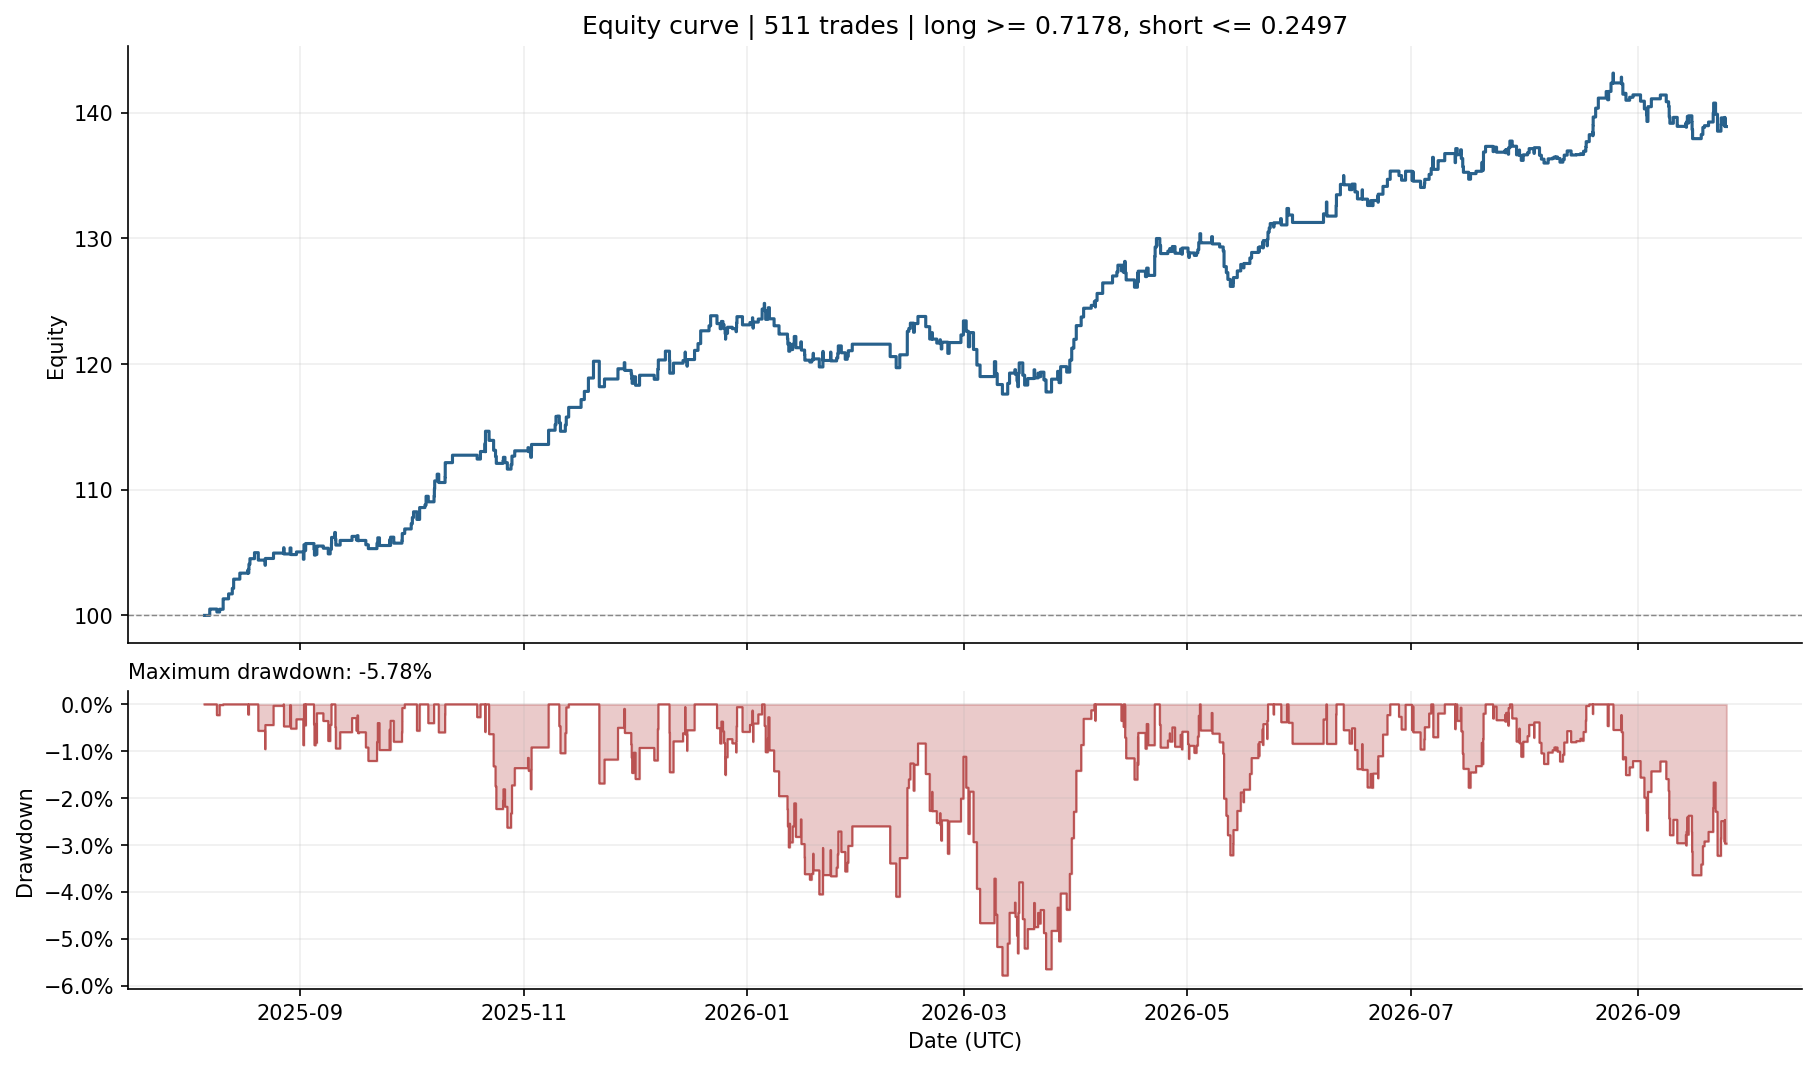

Trades:                     511
Win rate:                   59.10%
Average return per trade:   +0.0761%
Total return (fixed stake): +38.90%
Maximum drawdown:           -5.78%
Sharpe (annualized):        2.86


In [16]:
test_data = df_T1.tail(window_plot)
trades = backtest(test_data, LONG_THRESHOLD, SHORT_THRESHOLD)
equity, drawdown = equity_and_drawdown(trades, df_T1.tail(window_plot).index)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]}, layout='constrained')
axes[0].step(equity.index, equity, where='post', color='#28618c', linewidth=1.5)
axes[0].axhline(100, color='#888888', linewidth=0.7, linestyle='--')
axes[0].set_ylabel('Equity')
axes[0].set_title(
    f'Equity curve | {len(trades):,} trades | '
    f'long >= {LONG_THRESHOLD:.4f}, short <= {SHORT_THRESHOLD:.4f}'
)
axes[1].fill_between(drawdown.index, drawdown, 0, step='post', color='#ba5252', alpha=0.3)
axes[1].step(drawdown.index, drawdown, where='post', color='#ba5252', linewidth=1)
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1].set_xlabel('Date (UTC)')
max_drawdown = drawdown.min() if len(drawdown) else 0.0
axes[1].set_title(f'Maximum drawdown: {max_drawdown:.2f}%', loc='left', fontsize=10)
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
show_static(fig)

returns = trades['ret_pct']
span_years = (test_data.index[-1] - test_data.index[0]).total_seconds() / (365.25 * 24 * 3600)
sharpe = np.nan
if len(returns) > 1 and returns.std(ddof=1) > 0 and span_years > 0:
    sharpe = returns.mean() / returns.std(ddof=1) * np.sqrt(len(returns) / span_years)

print(f"Trades:                     {len(trades):,}")
print(f"Win rate:                   {100 * (returns > 0).mean():.2f}%")
print(f"Average return per trade:   {returns.mean():+.4f}%")
print(f"Total return (fixed stake): {returns.sum():+.2f}%")
print(f"Maximum drawdown:           {max_drawdown:.2f}%")
print(f"Sharpe (annualized):        {sharpe:.2f}")


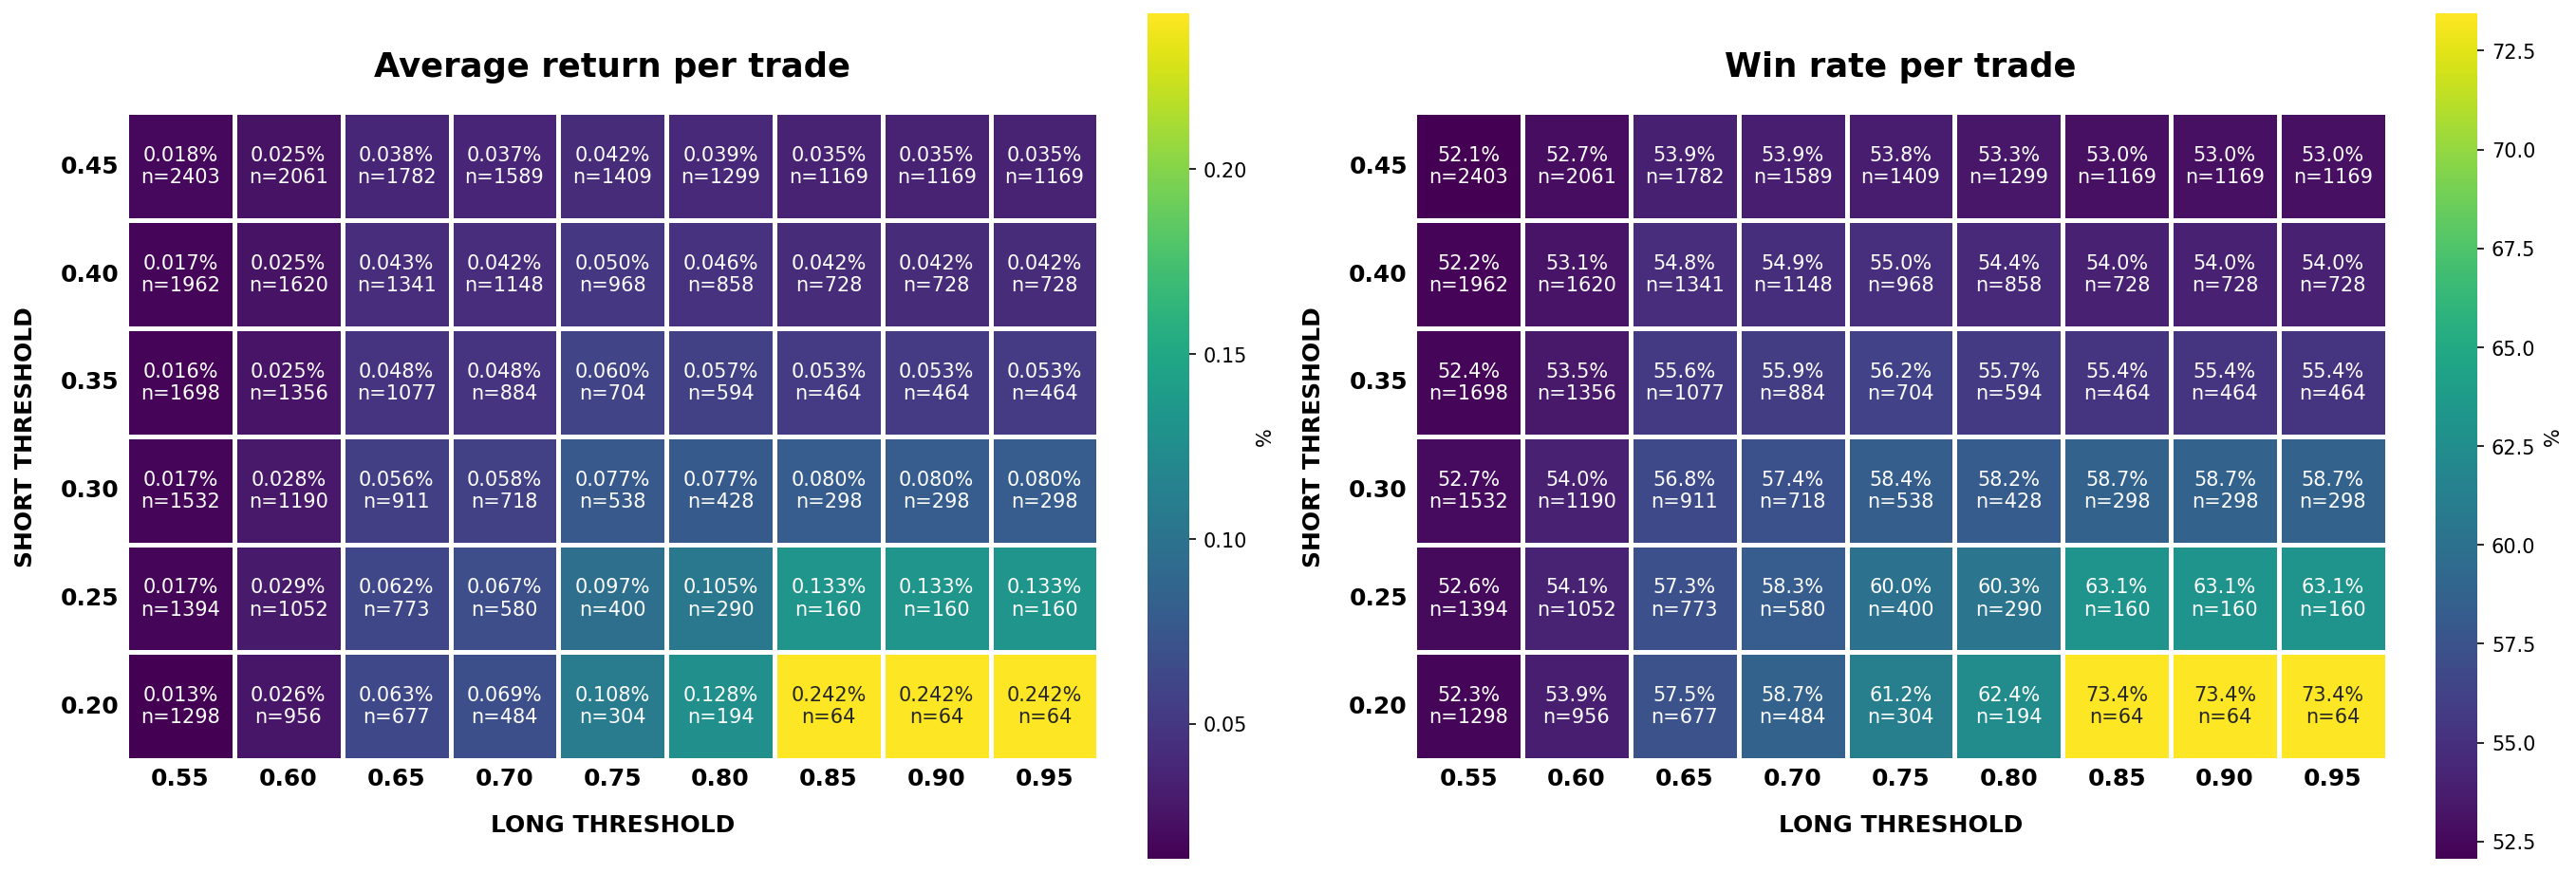

In [17]:
short_thresholds = np.round(np.arange(0.45, 0.19, -0.05), 2)
long_thresholds = np.round(np.arange(0.55, 0.96, 0.05), 2)

rows = []
for short in short_thresholds:
    for long in long_thresholds:
        selected = backtest(test_data, long, short)
        returns = selected['ret_pct']
        rows.append({
            'short_threshold': short,
            'long_threshold': long,
            'trades': len(selected),
            'average_return_pct': returns.mean(),
            'win_rate_pct': 100 * (returns > 0).mean() if len(selected) else np.nan,
        })
sweep = pd.DataFrame(rows)
counts = sweep.pivot(index='short_threshold', columns='long_threshold', values='trades')
counts = counts.reindex(index=short_thresholds, columns=long_thresholds)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), layout='constrained')
for ax, metric, title, decimals in [
    (axes[0], 'average_return_pct', 'Average return per trade', 3),
    (axes[1], 'win_rate_pct', 'Win rate per trade', 1),
]:
    values = sweep.pivot(index='short_threshold', columns='long_threshold', values=metric)
    values = values.reindex(index=short_thresholds, columns=long_thresholds)
    labels = np.array([
        [f'{value:.{decimals}f}%\nn={count}' if pd.notna(value) else ''
         for value, count in zip(value_row, count_row)]
        for value_row, count_row in zip(values.to_numpy(), counts.to_numpy())
    ])
    sns.heatmap(
        values, ax=ax, annot=labels, fmt='', cmap='viridis',
        linewidths=1.5, linecolor='white', square=True,
        annot_kws={'size': 10}, cbar_kws={'label': '%', 'shrink': 0.75},
        xticklabels=[f'{t:.2f}' for t in long_thresholds],
        yticklabels=[f'{t:.2f}' for t in short_thresholds],
        vmin=values.min().min() if values.notna().any().any() else 0,
        vmax=values.max().max() if values.notna().any().any() else 1,
    )
    ax.set_facecolor('#e5e7eb')
    for row, col in zip(*np.where(values.isna())):
        ax.text(col + 0.5, row + 0.5, 'No trades', ha='center', va='center', fontsize=9, color='#555555')
    ax.set_title(title, fontsize=17, weight='bold', pad=18)
    ax.set_xlabel('LONG THRESHOLD', fontsize=12, weight='bold', labelpad=12)
    ax.set_ylabel('SHORT THRESHOLD', fontsize=12, weight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=12, length=0)
    plt.setp(ax.get_xticklabels() + ax.get_yticklabels(), rotation=0, weight='bold')
show_static(fig)